#Este algoritmo sigue siendo un Branch and Bound, pero incorpora una técnica adicional llamada Cut (corte).

#La idea principal es:
#Branch  -> genera nuevas ramas
#Bound   -> poda ramas por estimación de costo
#Cut     -> elimina ramas usando reglas adicionales

In [1]:
import math
import time
import matplotlib.pyplot as plt

In [2]:
ciudades = [

    # Grupo A
    (10,10),
    (12,11),
    (11,13),
    (14,12),

    # Grupo B
    (45,45),
    (47,46),
    (44,48),
    (46,50),

    # Grupo C
    (85,15),
    (88,18),
    (86,21),
    (90,17),

    # Ciudades puente
    (30,25),
    (60,30),

    # Ciudades conflictivas
    (55,70),
    (25,60)
]

cantidad_ciudades = len(ciudades)

print("Cantidad de ciudades:", cantidad_ciudades)

Cantidad de ciudades: 16


In [3]:
def distancia(p1, p2):
    return math.sqrt(
        (p1[0] - p2[0])**2 +
        (p1[1] - p2[1])**2
    )

matriz = []

for i in range(cantidad_ciudades):

    fila = []

    for j in range(cantidad_ciudades):

        if i == j:
            fila.append(0)

        else:
            fila.append(
                distancia(
                    ciudades[i],
                    ciudades[j]
                )
            )

    matriz.append(fila)

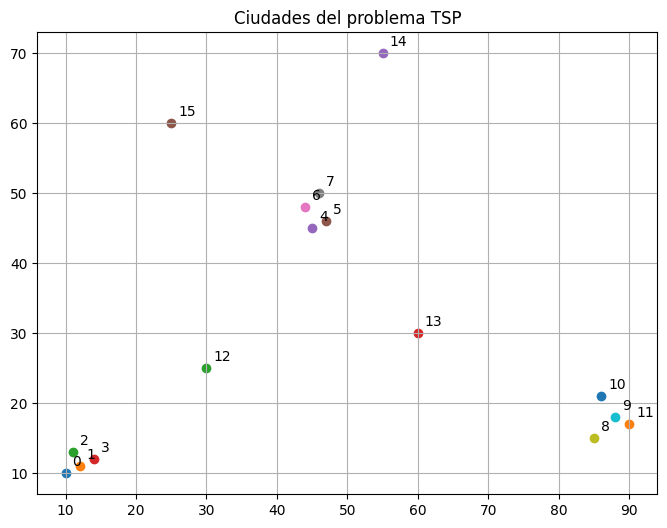

In [4]:
plt.figure(figsize=(8,6))

for indice, (x,y) in enumerate(ciudades):

    plt.scatter(x, y)

    plt.text(
        x + 1,
        y + 1,
        str(indice)
    )

plt.title("Ciudades del problema TSP")
plt.grid(True)

plt.show()

In [5]:
class EstadisticasCut:

    def __init__(self):

        self.nodos_explorados = 0
        self.nodos_podados = 0
        self.cortes_realizados = 0

In [9]:
def calcular_cota(
        ruta_actual,
        costo_actual,
        visitados,
        matriz):

    n = len(matriz)

    estimacion = costo_actual

    for ciudad in range(n):

        if ciudad not in visitados:

            menor = float('inf')

            for destino in range(n):

                if ciudad != destino:

                    if matriz[ciudad][destino] < menor:

                        menor = matriz[ciudad][destino]

            estimacion += menor

    return estimacion

In [6]:
def aplicar_corte(
        ciudad_actual,
        siguiente,
        matriz):

    costo_arista = matriz[ciudad_actual][siguiente]

    suma = 0
    contador = 0

    for fila in matriz:

        for valor in fila:

            if valor > 0:

                suma += valor
                contador += 1

    promedio = suma / contador

    if costo_arista > promedio * 1.5:

        return True

    return False

#Cut (Corte): Además de utilizar la cota de Branch and Bound, este algoritmo incorpora una regla adicional para eliminar ramas poco prometedoras. Antes de explorar una nueva ciudad, se analiza la distancia de la conexión. Si dicha distancia es considerablemente mayor que la distancia promedio de todas las conexiones del problema (en este caso, más de 1.5 veces el promedio), la rama se descarta inmediatamente sin seguir explorándola. La idea es evitar invertir tiempo en rutas que comienzan con desplazamientos excesivamente largos y que tienen pocas probabilidades de formar parte de la solución óptima

In [7]:
def branch_and_cut(matriz):

    n = len(matriz)

    mejor_costo = float('inf')
    mejor_ruta = None

    stats = EstadisticasCut()

    def explorar(
            ciudad_actual,
            visitados,
            ruta,
            costo_actual):

        nonlocal mejor_costo
        nonlocal mejor_ruta

        stats.nodos_explorados += 1

        if len(visitados) == n:

            costo_total = (
                costo_actual
                + matriz[ciudad_actual][0]
            )

            if costo_total < mejor_costo:

                mejor_costo = costo_total
                mejor_ruta = ruta[:] + [0]

            return

        limite = calcular_cota(
            ruta,
            costo_actual,
            visitados,
            matriz
        )

        if limite >= mejor_costo:

            stats.nodos_podados += 1
            return

        candidatos = []

        for ciudad in range(n):

            if ciudad not in visitados:

                candidatos.append(ciudad)

        candidatos.sort(
            key=lambda x:
            matriz[ciudad_actual][x]
        )

        for siguiente in candidatos:

            if aplicar_corte(
                    ciudad_actual,
                    siguiente,
                    matriz):

                stats.cortes_realizados += 1
                continue

            explorar(
                siguiente,
                visitados | {siguiente},
                ruta + [siguiente],
                costo_actual +
                matriz[ciudad_actual][siguiente]
            )

    explorar(
        0,
        {0},
        [0],
        0
    )

    return mejor_ruta, mejor_costo, stats

In [10]:
inicio = time.time()

ruta_cut, costo_cut, stats_cut = branch_and_cut(matriz)

fin = time.time()

tiempo_cut = fin - inicio

In [11]:
print("===== BRANCH AND CUT =====\n")

print("Ruta encontrada:")
print(ruta_cut)

print("\nCosto total:")
print(round(costo_cut,2))

print("\nNodos explorados:")
print(stats_cut.nodos_explorados)

print("\nNodos podados:")
print(stats_cut.nodos_podados)

print("\nCortes realizados:")
print(stats_cut.cortes_realizados)

print("\nTiempo:")
print(round(tiempo_cut,4),"segundos")

===== BRANCH AND CUT =====

Ruta encontrada:
[0, 1, 3, 12, 8, 11, 9, 10, 13, 5, 4, 6, 7, 14, 15, 2, 0]

Costo total:
254.33

Nodos explorados:
168124242

Nodos podados:
105921383

Cortes realizados:
50275267

Tiempo:
5258.5446 segundos


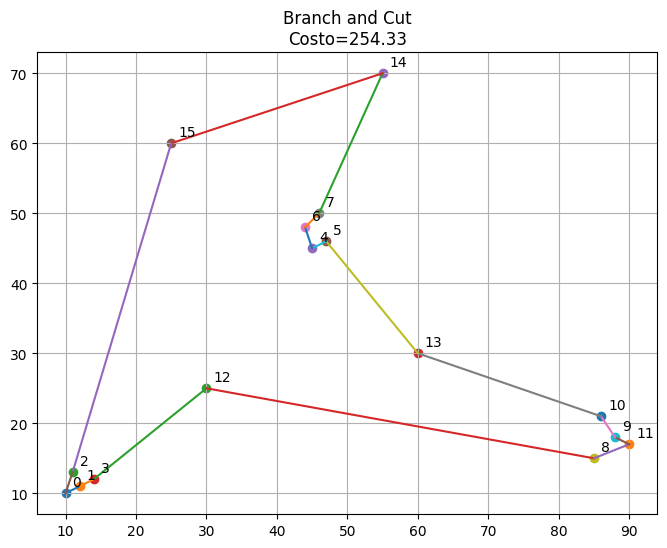

In [12]:
plt.figure(figsize=(8,6))

for i in range(len(ruta_cut)-1):

    a = ruta_cut[i]
    b = ruta_cut[i+1]

    x1,y1 = ciudades[a]
    x2,y2 = ciudades[b]

    plt.plot(
        [x1,x2],
        [y1,y2]
    )

for indice,(x,y) in enumerate(ciudades):

    plt.scatter(x,y)

    plt.text(
        x+1,
        y+1,
        str(indice)
    )

plt.title(
    f"Branch and Cut\nCosto={round(costo_cut,2)}"
)

plt.grid(True)

plt.show()

#Branch and Cut extiende Branch and Bound incorporando reglas de corte adicionales que permiten descartar conexiones consideradas poco prometedoras antes de expandirlas. En esta implementación, los cortes se aplican cuando una arista supera significativamente la distancia promedio del problema. Gracias a estos cortes y al ordenamiento de candidatos por cercanía, el algoritmo reduce la cantidad de nodos explorados y acelera la búsqueda de la solución óptima manteniendo el mismo costo final obtenido por Branch and Bound.